<a href="https://colab.research.google.com/github/JEAN-hub-lab/APPENDING-JOINING/blob/main/Final_343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# -----------------------------------------
# Import Libraries
# -----------------------------------------
import pandas as pd
import numpy as np

# -----------------------------------------
# Create DataFrames
# -----------------------------------------

# IoT Devices
devices = pd.DataFrame({
    "device_id": ["D1","D2","D3","D4"],
    "model": ["ESP32","ESP32","RPi","ESP8266"],
    "location_id": ["L1","L2","L3","L99"]
})

# Locations
locations = pd.DataFrame({
    "location_id": ["L1","L2","L3"],
    "building": ["A","A","B"],
    "room": ["101","102","Lab1"]
})

# Sensor Readings
readings = pd.DataFrame({
    "device_id": ["D1","D1","D2","D5"],
    "ts": ["2026-02-10 09:00",
           "2026-02-10 10:00",
           "2026-02-10 09:30",
           "2026-02-10 09:00"],
    "temp_c": [31.2, 31.8, 30.1, 29.9]
})

In [ ]:
# =========================================
# 1) Create iot_view (Left Join 3 Tables)
# =========================================

iot_view = readings.merge(devices, on='device_id', how='left') \
                   .merge(locations, on='location_id', how='left')

# Select only required columns (remove location_id)
col_order = ['device_id', 'ts', 'temp_c', 'model', 'building', 'room']
iot_view = iot_view[col_order]
#ทำเพื่อตัดคอลัมป์ที่อาจเกินมา เช่น location_id
print("=== iot_view ===")
print(iot_view)

=== iot_view ===
  device_id                ts  temp_c  model building room
0        D1  2026-02-10 09:00    31.2  ESP32        A  101
1        D1  2026-02-10 10:00    31.8  ESP32        A  101
2        D2  2026-02-10 09:30    30.1  ESP32        A  102
3        D5  2026-02-10 09:00    29.9    NaN      NaN  NaN


In [ ]:
# =========================================
# 1) Create iot_view (Left Join 3 Tables)
# =========================================

iot_view = readings.merge(devices,  on='device_id', how='outer') \
                   .merge(locations, on='location_id', how='outer')

# Select only required columns (remove location_id)
col_order = ['device_id', 'ts', 'temp_c', 'model', 'building', 'room']
iot_view = iot_view[col_order]
#ทำเพื่อตัดคอลัมป์ที่อาจเกินมา เช่น location_id
print("=== iot_view ===")
print(iot_view)

=== iot_view ===
  device_id                ts  temp_c    model building  room
0        D1  2026-02-10 09:00    31.2    ESP32        A   101
1        D1  2026-02-10 10:00    31.8    ESP32        A   101
2        D2  2026-02-10 09:30    30.1    ESP32        A   102
3        D3               NaN     NaN      RPi        B  Lab1
4        D4               NaN     NaN  ESP8266      NaN   NaN
5        D5  2026-02-10 09:00    29.9      NaN      NaN   NaN


In [ ]:
# =========================================
# 2) Show records where model is missing
# =========================================

missing_model = iot_view[iot_view['model'].isna()]
# ใช้ .isna() เช็คว่า เป็น true/False โดยเลือกคอลัมป์ model มาเช็ค จ่ากตา่ราง iot_view สั้นๆคือ df[df['column'].เงื่อนไข()]
missing_model_output = missing_model[['device_id', 'ts', 'temp_c']]

print("\n=== Missing Model ===")
print(missing_model_output)


=== Missing Model ===
  device_id                ts  temp_c
3        D5  2026-02-10 09:00    29.9


In [ ]:
# =========================================
# 3) Find devices pointing to invalid locations
# 3) ค้นหาอุปกรณ์ที่ชี้ไปยังตำแหน่งที่ไม่ถูกต้อง
# device ชี้ไป location ถูกต้องไหม
# =========================================

check_integrity = devices.merge(
    locations,
    on='location_id',
    how='left',
    indicator=True
    #indicator=True ใช้ทำอะไร?
      #ใช้สร้างคอลัมน์ _merge เพื่อบอกสถานะการ match ระหว่างสองตาราง
)
# df.merge(df2, indicator=True) แบบสั้นๆ

invalid_location_ref = check_integrity[
    check_integrity['_merge'] == 'left_only'
]

print("\n=== Invalid Location Reference ===")
print(invalid_location_ref)


=== Invalid Location Reference ===
  device_id    model location_id building room     _merge
3        D4  ESP8266         L99      NaN  NaN  left_only


df.merge(df2, indicator=True) แบบสั้นๆ

In [ ]:
# =========================================
# 4) Average temp_c per building (include NaN)
# =========================================

avg_temp_by_building = iot_view.groupby(
    'building',
    dropna=False
)[['temp_c']].mean()

print("\n=== Average Temp by Building ===")
print(avg_temp_by_building)


=== Average Temp by Building ===
             temp_c
building           
A         31.033333
NaN       29.900000


appending pd.concat

In [ ]:
import pandas as pd
# สร้าง DataFrame เดือน May
sales_may = pd.DataFrame({
    "date": ["2022-05-01", "2022-05-01", "2022-05-01"],
    "store": [1, 2, 3],
    "sales": [341, 291, 493]
})
# สร้าง DataFrame เดือน June
sales_june = pd.DataFrame({
    "date": ["2022-06-01", "2022-06-01", "2022-06-01"],
    "store": [1, 2, 3],
    "sales": [67, 144, 226]
})
print("=== sales_may ===")
print(sales_may)
print("\n=== sales_june ===")
print(sales_june)

=== sales_may ===
         date  store  sales
0  2022-05-01      1    341
1  2022-05-01      2    291
2  2022-05-01      3    493

=== sales_june ===
         date  store  sales
0  2022-06-01      1     67
1  2022-06-01      2    144
2  2022-06-01      3    226


ใช้ pd.concat (axis=0) เพื่อต่อแถวแนวตั้งเรียงลงมา(row)

In [ ]:
sales_all = pd.concat([sales_may, sales_june])
print("\n=== หลัง concat ===")
print(sales_all)


=== หลัง concat ===
         date  store  sales
0  2022-05-01      1    341
1  2022-05-01      2    291
2  2022-05-01      3    493
0  2022-06-01      1     67
1  2022-06-01      2    144
2  2022-06-01      3    226


In [ ]:
sales_nawnon = pd.concat([sales_may,sales_june],axis=1)
print("\n=== concat แนวนอน (axis=1) ===")
print(sales_nawnon)


=== concat แนวนอน (axis=1) ===
         date  store  sales        date  store  sales
0  2022-05-01      1    341  2022-06-01      1     67
1  2022-05-01      2    291  2022-06-01      2    144
2  2022-05-01      3    493  2022-06-01      3    226


In [ ]:
sales_all_reset = pd.concat([sales_may, sales_june], ignore_index=True)

print("\n=== หลัง concat + reset index ===")
print(sales_all_reset)


=== หลัง concat + reset index ===
         date  store  sales
0  2022-05-01      1    341
1  2022-05-01      2    291
2  2022-05-01      3    493
3  2022-06-01      1     67
4  2022-06-01      2    144
5  2022-06-01      3    226


ignore_index=True คือการเรียงลำดับ indexใหม่ ทำให้ข้อมูลสะอาดขึ้นกว่าเดิม

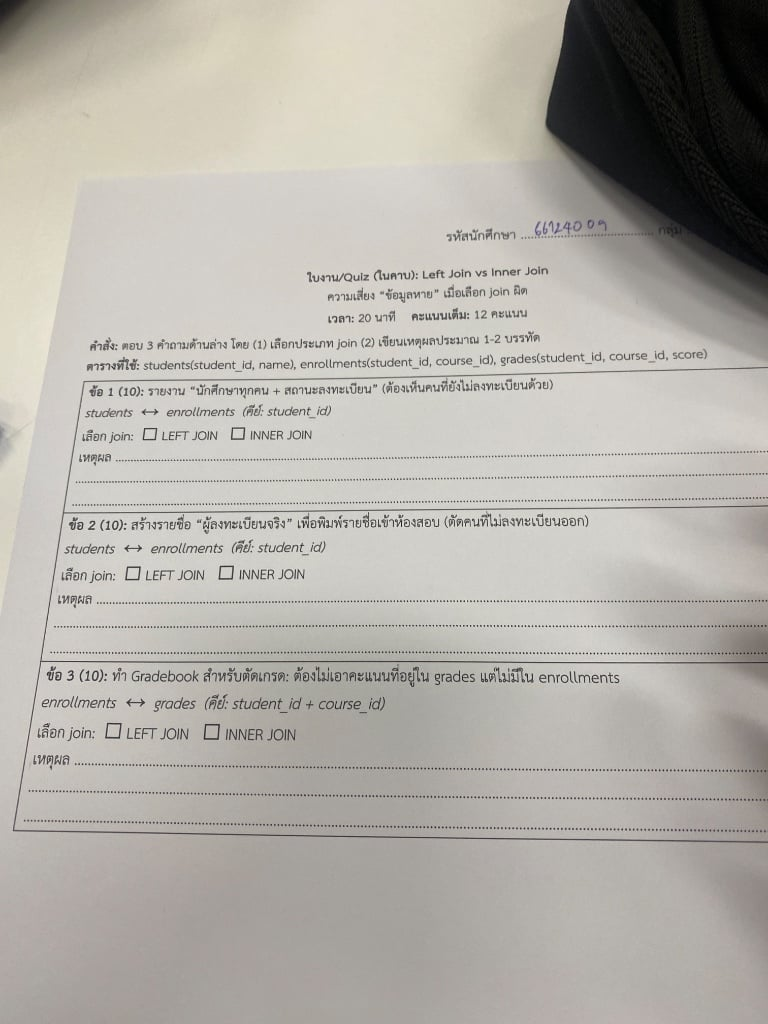

In [ ]:
enrollments.merge(grades,on=['student_id', 'course_id'],how='inner')

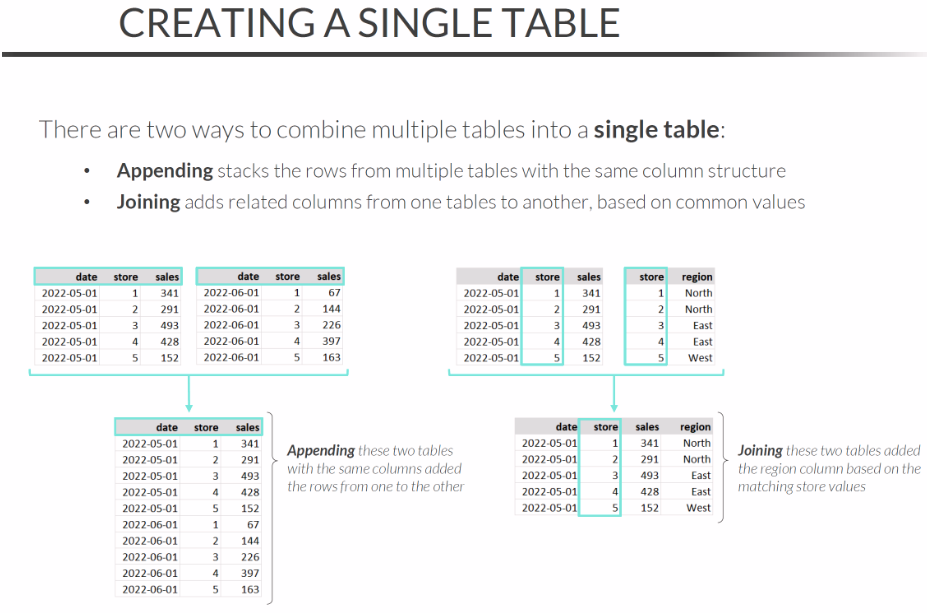

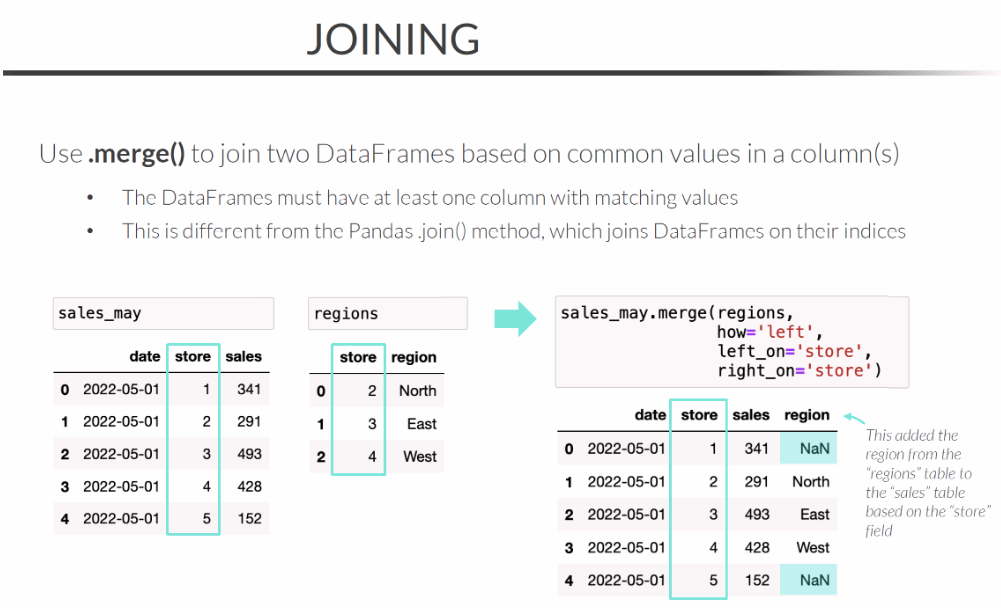

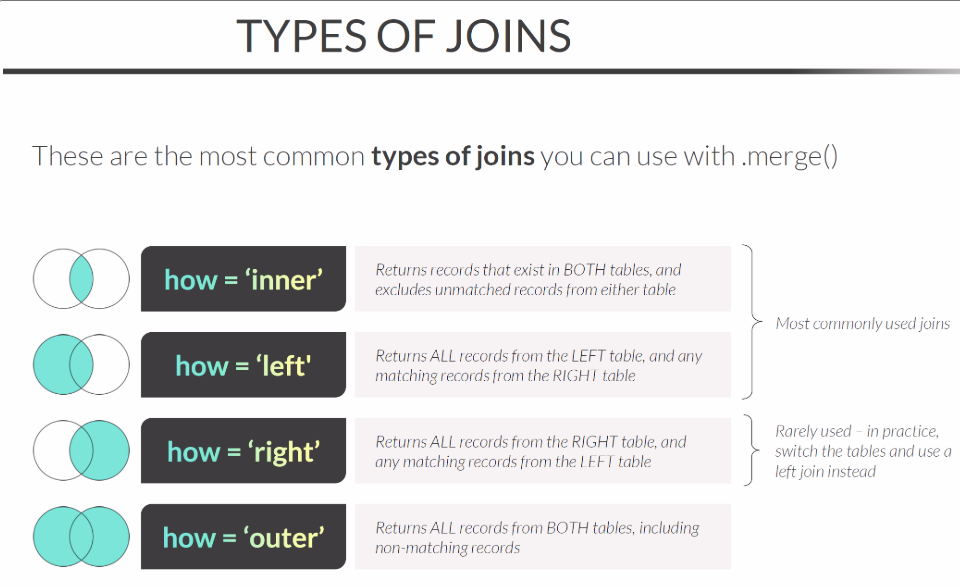

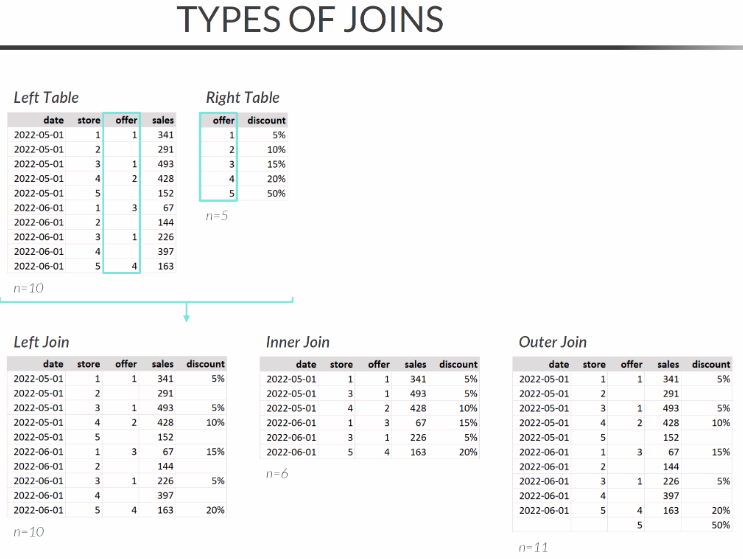